# Fundamentals of Cryptography


In [1]:
# These imports have been used throughout
import os, hashlib, hmac, struct, secrets
from textwrap import wrap
print('All standard-library imports loaded.')

All standard-library imports loaded.


---
<a id='sec1'></a>
## 1 · Shared Secret Keys

A **shared secret key** is a random value known only to the communicating parties. It is the principal component of symmetric cryptography

| Property | Significance |
|---|---|
| **Randomness** | Predictable keys can be guessed |
| **Length** | 128 / 256 bits common; longer resists brute force |
| **Secrecy** | Anyone with the key can forge or read messages |
| **Out-of-band exchange** | Must be shared securely *before* communication |

```
Alice ────────> shared key K ────────> Bob
        (agreed in advance, kept secret)
```

In [2]:
# Generating cryptographically secure keys

# os.urandom draws from the OS CSPRNG (/dev/urandom on Linux)
key_128 = os.urandom(16)          # 128-bit key / 16 byte 
key_256 = os.urandom(32)          # 256-bit key

key_secrets = secrets.token_bytes(32)

print(f'128-bit key : {key_128.hex()}')
print(f'256-bit key : {key_256.hex()}')
print(f'secrets key : {key_secrets.hex()}')
print(f'Key length  : {len(key_256)} bytes = {len(key_256)*8} bits')

128-bit key : a6eaff885fb588b56ff2b0323835246d
256-bit key : 1e66cf1dbfdeeea8679ba78a6578b27c7a2172e447d32573e842d279a9371478
secrets key : da508ce645ac1715b38130022f22f109bb3b9c3f079eda0c4b12a4d1ef8912e9
Key length  : 32 bytes = 256 bits


In [21]:
# Why randomness matters
import random

def weak_key(n_bits):
    random.seed(4)   # Fixed seed => same key every run(this is bad obviously)
    return random.getrandbits(n_bits)

print('Weak key (seeded PRNG, always same):', hex(weak_key(128)))
print('Weak key (seeded PRNG, always same):', hex(weak_key(128)))
print()
print('Strong key (CSPRNG, unique each time):', os.urandom(16).hex())
print('Strong key (CSPRNG, unique each time):', os.urandom(16).hex())

Weak key (seeded PRNG, always same): 0xb8a1abcd1a6916c74da4f9fc3c6da5d7
Weak key (seeded PRNG, always same): 0xb8a1abcd1a6916c74da4f9fc3c6da5d7

Strong key (CSPRNG, unique each time): 559537c310dc7ffa64b122274a0b76f5
Strong key (CSPRNG, unique each time): 1a99e32a419c8029fc0f282fa423c4e7


---
<a id='sec2'></a>
## 2 · Hash Functions — Concepts & Properties

A **cryptographic hash function** maps arbitrary-length input to a fixed-length *output space*: `H : {0,1}* → {0,1}^n`

| Property | Definition |
|---|---|
| **Deterministic** | Same input → same output |
| **Pre-image resistant** | Given `h`, can't find `m` s.t. `H(m)=h` |
| **Second pre-image resistant** | Given `m1`, can't find `m2≠m1` with same hash |
| **Collision resistant** | Can't find any `m1≠m2` with same hash |
| **Avalanche effect** | 1-bit input change flips ~50% output bits |

In [ ]:
# Demonstrating hash properties
def sha256(data):
    # Return hex string (64 hex chars = 256 bits)
    return hashlib.sha256(data).hexdigest()

# Determinism
msg = b'Hello, Cryptography!'
print('=== Determinism (same output both times) ===')
print(sha256(msg))
print(sha256(msg))

# Avalanche effect
msg1 = b'Hello, Cryptography!'
msg2 = b'Hello, cryptography!'  # lowercase 'c'
h1, h2 = sha256(msg1), sha256(msg2)
print('\n=== Avalanche Effect ===')
print(f'H(msg1) = {h1}')
print(f'H(msg2) = {h2}')

# Convert hex digest back to a 256-character '0'/'1' string so we can compare bits:
# 1) int(h, 16)   => parse hex into an integer
# 2) bin(...)[2:] => produce binary text (remove '0b' prefix)
# 3) zfill(256)   => pad with leading zeros to exactly 256 bits
bits1 = bin(int(h1, 16))[2:].zfill(256)
bits2 = bin(int(h2, 16))[2:].zfill(256)
# Count differing bits by zipping the two bit-strings
diff  = sum(b1 != b2 for b1, b2 in zip(bits1, bits2))
print(f'Bits differing: {diff}/256  ({diff/256*100:.1f}%)  <- ideal ~50%')

=== Determinism (same output both times) ===
29aff889935f5a275ec562ef46c138e917a270aab79b4d5577ee8ea5af308f73
29aff889935f5a275ec562ef46c138e917a270aab79b4d5577ee8ea5af308f73

=== Avalanche Effect ===
H(msg1) = 29aff889935f5a275ec562ef46c138e917a270aab79b4d5577ee8ea5af308f73
H(msg2) = 4e5e1f2afe7756a444cd8c75166c17d7762ccfe7bc96060879c224bd1aa5d8c6
Bits differing: 127/256  (49.6%)  <- ideal ~50%


In [5]:
# Fixed output length regardless of input size

inputs = [b'', b'a', b'The quick brown fox jumps over the lazy dog', b'x'*10_000]

print(f'{"Input preview":<45} {"Len":>6}  Digest')
print('-'*100)
for inp in inputs:
    preview = repr(inp[:40])[2:-1] + ('...' if len(inp)>40 else '')
    print(f'{preview:<45} {len(inp):>6}  {sha256(inp)}')

Input preview                                    Len  Digest
----------------------------------------------------------------------------------------------------
                                                   0  e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855
a                                                  1  ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb
The quick brown fox jumps over the lazy ...       43  d7a8fbb307d7809469ca9abcb0082e4f8d5651e46d3cdb762d02d0bf37c9e592
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx...    10000  e4ee97ec252749d2096447e849628d0d7734f51700416eefbb33574bf0b3ee75


In [ ]:
print(b'Hello, World!')
repr(b'Hello, World!')

b'Hello, World!'


"b'Hello, World!'"

---
<a id='sec3'></a>
## 3 · SHA-256 — From Scratch

SHA-256 (SECURE HASH ALGORITHM 256)  is part of the SHA-2 family (NIST, 2001). It processes data in **512-bit blocks** using a **Merkle-Damgård construction**.

```
Message M
  |
  v
1. Pre-processing  -- pad M to multiple of 512 bits
  |
  v (512-bit blocks)
2. For each block:
   - Message schedule  (expand 16 words to  -> 64 words each word = 32 bits )
   - 64 rounds         (mix with round constants K[i])
   - Add to state H    (compress into 8x32-bit words)
  |
  v
3. Final digest   -- concatenate H[0..7] = 256 bits
```

In [ ]:
# Reference: FIPS PUB 180-4

class SHA256:
    # Initial hash values H[0..7]:
    # First 32 bits of fractional parts of sqrt of first 8 primes.
    H0 = [
        0x6a09e667, 0xbb67ae85, 0x3c6ef372, 0xa54ff53a,
        0x510e527f, 0x9b05688c, 0x1f83d9ab, 0x5be0cd19,
    ]

    # Round constants K[0..63]:
    # First 32 bits of fractional parts of cbrt of first 64 primes.
    K = [
        0x428a2f98,0x71374491,0xb5c0fbcf,0xe9b5dba5,
        0x3956c25b,0x59f111f1,0x923f82a4,0xab1c5ed5,
        0xd807aa98,0x12835b01,0x243185be,0x550c7dc3,
        0x72be5d74,0x80deb1fe,0x9bdc06a7,0xc19bf174,
        0xe49b69c1,0xefbe4786,0x0fc19dc6,0x240ca1cc,
        0x2de92c6f,0x4a7484aa,0x5cb0a9dc,0x76f988da,
        0x983e5152,0xa831c66d,0xb00327c8,0xbf597fc7,
        0xc6e00bf3,0xd5a79147,0x06ca6351,0x14292967,
        0x27b70a85,0x2e1b2138,0x4d2c6dfc,0x53380d13,
        0x650a7354,0x766a0abb,0x81c2c92e,0x92722c85,
        0xa2bfe8a1,0xa81a664b,0xc24b8b70,0xc76c51a3,
        0xd192e819,0xd6990624,0xf40e3585,0x106aa070,
        0x19a4c116,0x1e376c08,0x2748774c,0x34b0bcb5,
        0x391c0cb3,0x4ed8aa4a,0x5b9cca4f,0x682e6ff3,
        0x748f82ee,0x78a5636f,0x84c87814,0x8cc70208,
        0x90befffa,0xa4506ceb,0xbef9a3f7,0xc67178f2,
    ]

    @staticmethod
    def _rotr(x, n):
        """Right-rotate a 32-bit integer by n positions."""
        return ((x >> n) | (x << (32 - n))) & 0xFFFFFFFF

    @staticmethod
    def _pad(message):
        """
        SHA-256 padding (FIPS 180-4 Sec 5.1.1):
1

          2. Append zero bytes until len(msg) % 64 == 56
          3. Append original bit-length as 64-bit big-endian
        """
        length_bits = len(message) * 8
        message    += b'\x80'
        while len(message) % 64 != 56:
            message += b'\x00'
        message += struct.pack('>Q', length_bits)
        return message

    def _compress(self, block, H):
        """Process one 512-bit block; return new hash state."""
        # Expand 16 -> 64 words
        W = list(struct.unpack('>16I', block)) # break each block of 64 bytes into chunks of 16 of int data type (4 bytes) and unpack accordingly
        for i in range(16, 64):
            s0 = self._rotr(W[i-15], 7)  ^ self._rotr(W[i-15], 18) ^ (W[i-15] >> 3)
            s1 = self._rotr(W[i-2],  17) ^ self._rotr(W[i-2],  19) ^ (W[i-2]  >> 10)
            W.append((W[i-16] + s0 + W[i-7] + s1) & 0xFFFFFFFF)

        a, b, c, d, e, f, g, h = H

        for i in range(64):
            S1    = self._rotr(e,6)  ^ self._rotr(e,11) ^ self._rotr(e,25)
            ch    = (e & f) ^ (~e & g)
            temp1 = (h + S1 + ch + self.K[i] + W[i]) & 0xFFFFFFFF
            S0    = self._rotr(a,2)  ^ self._rotr(a,13) ^ self._rotr(a,22)
            maj   = (a & b) ^ (a & c) ^ (b & c)
            temp2 = (S0 + maj) & 0xFFFFFFFF
            h=g; g=f; f=e
            e = (d + temp1) & 0xFFFFFFFF
            d=c; c=b; b=a
            a = (temp1 + temp2) & 0xFFFFFFFF

        return [(x+y) & 0xFFFFFFFF for x,y in zip(H,[a,b,c,d,e,f,g,h])]

    def hash(self, message):
        H      = list(self.H0)
        padded = self._pad(message)
        for i in range(0, len(padded), 64):
            H = self._compress(padded[i:i+64], H)
        return ''.join(f'{w:08x}' for w in H)


# Verify against hashlib
sha = SHA256()
vectors = [b'', b'abc', b'The quick brown fox jumps over the lazy dog', b'hello world']
print(f'{"Input":<45} Match?')
print('-'*70)
all_ok = True
for msg in vectors:
    ours = sha.hash(msg)
    ref  = hashlib.sha256(msg).hexdigest()
    ok   = ours == ref 
    if not ok: all_ok = False
    mark = 'PASS' if ok else 'FAIL'
    print(f'{repr(msg):<45} {mark}  {ours}')
print()
print('All test vectors passed!' if all_ok else 'MISMATCH DETECTED!')

Input                                         Match?
----------------------------------------------------------------------
b''                                           PASS  e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855
b'abc'                                        PASS  ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad
b'The quick brown fox jumps over the lazy dog' PASS  d7a8fbb307d7809469ca9abcb0082e4f8d5651e46d3cdb762d02d0bf37c9e592
b'hello world'                                PASS  b94d27b9934d3e08a52e52d7da7dabfac484efe37a5380ee9088f7ace2efcde9

All test vectors passed!


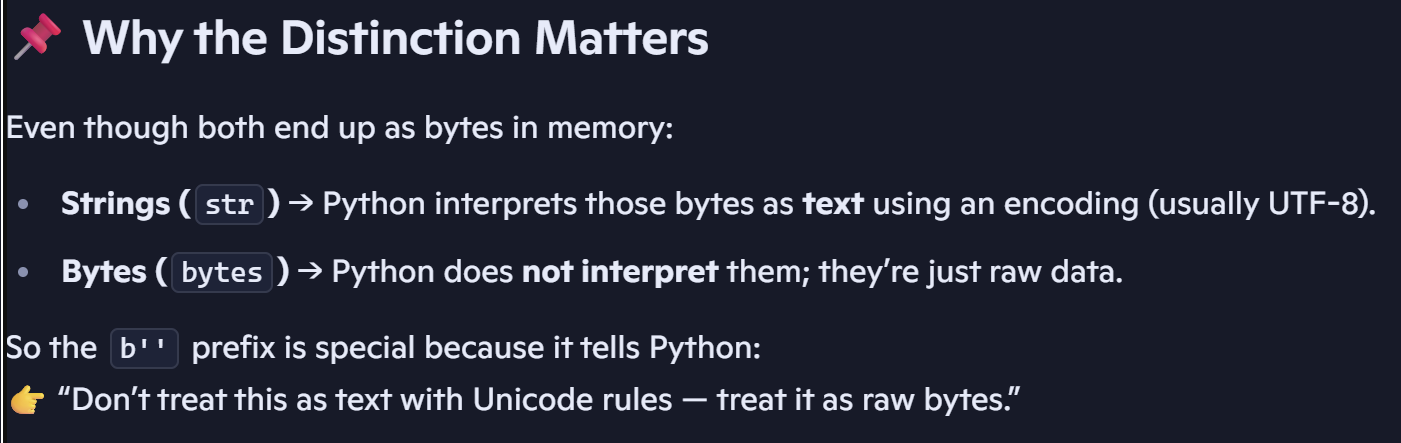 

In [ ]:
# padding stage

msg    = b'abc'
padded = SHA256._pad(msg)

print(f'Original : {msg!r}  ({len(msg)} bytes = {len(msg)*8} bits)')
print(f'Padded   : {len(padded)} bytes = {len(padded)*8} bits (one 512-bit block)')
print()
# We print the padded bytes as hex, 16 bytes per row for readability.
# 16 bytes == 32 hex chars, so we slice the hex string in chunks of 32.
print('Padded bytes (hex, 16 bytes per row):')
h = padded.hex()
rows = [h[i:i+32] for i in range(0, len(h), 32)]
for idx, row in enumerate(rows):
    # each 'row' is 32 hex chars => 16 bytes
    pairs = ' '.join(row[j:j+2] for j in range(0, len(row), 2))
    # idx*16 and idx*16+15 show the byte index range for that row
    print(f'  [{idx*16:02d}-{idx*16+15:02d}]  {pairs}')
print()
print('Last 8 bytes = original bit-length big-endian:')
print(f'  {len(msg)*8} bits => {struct.pack(">Q", len(msg)*8).hex()}')

Original : b'abc'  (3 bytes = 24 bits)
Padded   : 64 bytes = 512 bits (one 512-bit block)

Padded bytes (hex, 16 bytes per row):
  [00-15]  61 62 63 80 00 00 00 00 00 00 00 00 00 00 00 00
  [16-31]  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00
  [32-47]  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00
  [48-63]  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 18

Last 8 bytes = original bit-length big-endian:
  24 bits => 0000000000000018


---
<a id='sec4'></a>
## 4 · Message Authentication Codes (MACs)

A plain hash provides **integrity** but not **authentication** — anyone can compute `H(m)`.  
A **MAC** binds the message to a secret key so only key-holders can produce or verify tags:

```
tag = MAC(key, message)
```

| Goal | Explanation |
|---|---|
| **Correctness** | `Verify(key, msg, MAC(key,msg))` always True |
| **Unforgeability** | Without the key, attacker cannot produce a valid `(msg, tag)` |
| **Tag uniqueness** | Different messages → different tags (w.h.p.) |

### Naive `H(key ‖ message)` — Length-Extension Attack

Simply prepending the key is **insecure** for Merkle-Damgård hashes (SHA-256 included).  
An attacker who knows `H(key ‖ m)` and `len(key)` can extend the message without knowing the key.

In [8]:
# Naive MAC

def naive_mac(key, message):
    return hashlib.sha256(key + message).hexdigest()

def verify_naive(key, message, tag):
    return naive_mac(key, message) == tag

key = secrets.token_bytes(32)
msg = b'amount=100&to=alice'

tag = naive_mac(key, msg)
print(f'Message : {msg.decode()}')
print(f'Tag     : {tag}')
print(f'Verify  : {verify_naive(key, msg, tag)}')
print()
print('WARNING: This construction is vulnerable to length-extension attacks.')
print('Use HMAC (Section 5) instead.')

Message : amount=100&to=alice
Tag     : ee0add849b4998d84c7c77a7be05692717e6059a7b3920e96fbe216f4f79aa4a
Verify  : True

Use HMAC (Section 5) instead.


In [9]:
# Constant-time comparison -- preventing timing attacks
# Python's == short-circuits on the first differing byte, leaking timing information an attacker can exploit byte-by-byte.
# hmac.compare_digest always runs in O(n) time

import time

tag_a = 'a' * 64          # correct tag
tag_b = 'a' * 63 + 'b'   # differs at last byte
tag_c = 'b' + 'a' * 63   # differs at first byte

def bench(t1, t2, fn, label, n=200_000):
    start = time.perf_counter()
    for _ in range(n): fn(t1, t2)
    us = (time.perf_counter() - start) * 1e6 / n
    print(f'  {label}: {us:.4f} us/call')

print('tag_a vs tag_b (differ at LAST byte):')
bench(tag_a, tag_b, lambda a,b: a==b,            'Python ==          ')
bench(tag_a, tag_b, hmac.compare_digest,          'hmac.compare_digest')

print('tag_a vs tag_c (differ at FIRST byte):')
bench(tag_a, tag_c, lambda a,b: a==b,            'Python ==          ')
bench(tag_a, tag_c, hmac.compare_digest,          'hmac.compare_digest')

print()
print('hmac.compare_digest takes the same time regardless of where tags diverge.')

tag_a vs tag_b (differ at LAST byte):
  Python ==          : 0.0270 us/call
  hmac.compare_digest: 0.0498 us/call
tag_a vs tag_c (differ at FIRST byte):
  Python ==          : 0.0284 us/call
  hmac.compare_digest: 0.0513 us/call

hmac.compare_digest takes the same time regardless of where tags diverge.


---
<a id='sec5'></a>
## 5 · HMAC Construction

**HMAC** (RFC 2104) is the standard way to build a secure MAC from any hash function.

### Formula

```
HMAC(K, m) = H( (K' XOR opad) || H( (K' XOR ipad) || m ) )
```

Where:
- `K'`   = key padded/hashed to block size B (64 bytes for SHA-256)
- `ipad` = 0x36 repeated B times
- `opad` = 0x5C repeated B times

### Why two nested hashes?
The inner hash binds `key || message` under `ipad`.  
The outer hash then re-signs the inner digest with `opad`.  
This double-wrapping **defeats length-extension attacks** even for SHA-2.

```
K' XOR ipad  -->  H( ipad_key || m )  -->  inner digest
                                                  |
K' XOR opad  -->  H( opad_key || inner ) --> HMAC tag
```

In [10]:
# HMAC-SHA256 from scratch (RFC 2104)

def hmac_sha256_scratch(key, message):
    B    = 64             # block size
    ipad = bytes([0x36] * B)
    opad = bytes([0x5C] * B)

    # if key > B bytes, replace with its hash
    if len(key) > B:
        key = hashlib.sha256(key).digest()

    # pad key with zeros to length B
    key = key.ljust(B, b'\x00')

    # XOR key with ipad and opad
    k_ipad = bytes(k ^ i for k, i in zip(key, ipad))
    k_opad = bytes(k ^ o for k, o in zip(key, opad))

    # inner hash
    inner = hashlib.sha256(k_ipad + message).digest()

    # outer hash
    return hashlib.sha256(k_opad + inner).hexdigest()


key      = secrets.token_bytes(32)
long_key = secrets.token_bytes(100)
msgs = [
    (key,      b''),
    (key,      b'Hello!'),
    (key,      b'amount=100&to=alice'),
    (key,      b'The quick brown fox jumps over the lazy dog'),
    (key,      secrets.token_bytes(200)),
    (long_key, b'test with long key'),
]

print(f'{"#":<4} Match?  Tag (first 32 chars)')
print('-'*60)
all_ok = True
for i, (k, m) in enumerate(msgs):
    ours = hmac_sha256_scratch(k, m)
    ref  = hmac.new(k, m, hashlib.sha256).hexdigest()
    ok   = ours == ref
    if not ok: all_ok = False
    print(f'[{i+1}]  {"PASS" if ok else "FAIL"}    {ours[:32]}...')
print()
print('All HMAC vectors matched!' if all_ok else 'MISMATCH DETECTED!')

#    Match?  Tag (first 32 chars)
------------------------------------------------------------
[1]  PASS    177e996ddf35dd02b6773232a2f98140...
[2]  PASS    2abc988b59ecd1673166a3abfd3985be...
[3]  PASS    ebb05bef662c404c90f7884f66959f20...
[4]  PASS    1345815dd2d49560d22af02a9125ba4c...
[5]  PASS    6676bd24ad6b499b4ef85cc4ce92c4ef...
[6]  PASS    03aeed35e6332e56256551f06ef92973...

All HMAC vectors matched!


In [11]:
# 5.2  HMAC with Python standard library

def make_hmac(key, message):
    """Return raw 32-byte HMAC-SHA256 tag."""
    return hmac.new(key, message, hashlib.sha256).digest()

def verify_hmac(key, message, tag):
    """Constant-time HMAC verification."""
    return hmac.compare_digest(make_hmac(key, message), tag)

key     = secrets.token_bytes(32)
message = b'Transfer $500 to Bob'
tag     = make_hmac(key, message)

print(f'Message          : {message.decode()}')
print(f'HMAC tag (hex)   : {tag.hex()}')
print()
print('Verify correct message :', verify_hmac(key, message, tag))
print('Verify tampered message:', verify_hmac(key, b'Transfer $999 to Bob', tag))
print('Verify wrong key       :', verify_hmac(secrets.token_bytes(32), message, tag))

Message          : Transfer $500 to Bob
HMAC tag (hex)   : fd6008d53b1181c149d89f04e0c9c845f4e1a46725fe7fb923fcaffbbfaf68c4

Verify correct message : True
Verify tampered message: False
Verify wrong key       : False


In [12]:
# 5.3  Visual: inspect the ipad/opad XOR layers

key_demo = b'mysecretkey'
B = 64
k_padded = key_demo.ljust(B, b'\x00')
k_ipad   = bytes(k ^ 0x36 for k in k_padded)
k_opad   = bytes(k ^ 0x5C for k in k_padded)

print('Key padded to 64 bytes:')
print(' ', k_padded.hex())
print('k XOR ipad (0x36):')
print(' ', k_ipad.hex())
print('k XOR opad (0x5C):')
print(' ', k_opad.hex())

msg_demo  = b'hello'
inner_raw = hashlib.sha256(k_ipad + msg_demo).digest()
outer_hex = hashlib.sha256(k_opad + inner_raw).hexdigest()

print()
print('Inner hash H(k_ipad || msg):')
print(' ', inner_raw.hex())
print('Final HMAC H(k_opad || inner):')
print(' ', outer_hex)

Key padded to 64 bytes:
  6d797365637265746b65790000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
k XOR ipad (0x36):
  5b4f4553554453425d534f3636363636363636363636363636363636363636363636363636363636363636363636363636363636363636363636363636363636
k XOR opad (0x5C):
  31252f393f2e39283739255c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c5c

Inner hash H(k_ipad || msg):
  6929e969659856e90dda5c9a10598f59c6baa169bb330a9f16f27b58ac7b0984
Final HMAC H(k_opad || inner):
  47d06abc58acb49b15ede3d7ae68cc9202edfac0b69ff989c2b8041ad86c1758


---
<a id='sec6'></a>
## 6 . Demo

A complete authenticated message exchange between **Alice** and **Bob** sharing a secret key.

```
Alice                          Bob
  |                             |
  |-- (message, HMAC tag) ----> |
  |                             |  verify tag
  | <-- (reply, HMAC tag) ----- |
  |  verify tag                 |
  |                             |
  | Eve intercepts & tampers|
  |-- (tampered msg, old tag) ->|
  |                             |  REJECT: tag invalid
```

In [13]:
# 6.1  AuthenticatedChannel class

class AuthenticatedChannel:
    """Simple authenticated channel using HMAC-SHA256."""

    def __init__(self, shared_key):
        self.key = shared_key

    def send(self, message):
        """Return an authenticated packet dict."""
        msg_bytes = message.encode()
        tag       = hmac.new(self.key, msg_bytes, hashlib.sha256).digest()
        return {'message': message, 'tag': tag.hex()}

    def receive(self, packet):
        """Verify tag and return message, or raise on failure."""
        msg_bytes = packet['message'].encode()
        tag_recv  = bytes.fromhex(packet['tag'])
        tag_exp   = hmac.new(self.key, msg_bytes, hashlib.sha256).digest()
        if not hmac.compare_digest(tag_exp, tag_recv):
            raise ValueError('Authentication FAILED -- message tampered!')
        return packet['message']


SHARED_KEY = secrets.token_bytes(32)
print(f'Shared key: {SHARED_KEY.hex()[:32]}...  ({len(SHARED_KEY)} bytes)\n')

alice = AuthenticatedChannel(SHARED_KEY)
bob   = AuthenticatedChannel(SHARED_KEY)

# Alice sends
pkt = alice.send('Transfer $100 to Charlie')
print(f'Alice sends  -> "{pkt["message"]}"')
print(f'               tag: {pkt["tag"][:32]}...')

# Bob receives
try:
    print(f'\nBob receives -> VERIFIED: "{bob.receive(pkt)}"')
except ValueError as e:
    print(f'\nBob receives -> {e}')

# Eve tampers
tampered = {'message': 'Transfer $9999 to Eve', 'tag': pkt['tag']}
print(f'\nEve tampers -> "{tampered["message"]}"')
try:
    print(f'Bob receives -> VERIFIED: "{bob.receive(tampered)}"')
except ValueError as e:
    print(f'Bob receives -> {e}')

Shared key: 7806c178fab47a8f9469200e83739a5e...  (32 bytes)

Alice sends  -> "Transfer $100 to Charlie"
               tag: 0e7c05c0e625290bf5895f019b44bdf2...

Bob receives -> VERIFIED: "Transfer $100 to Charlie"

Eve tampers -> "Transfer $9999 to Eve"
Bob receives -> Authentication FAILED -- message tampered!
